In [1]:
import os, sys

# install deps only once
if not os.path.exists("/kaggle/working/.setup_done"):
    !pip install -q nibabel opencv-python tqdm
    
    if not os.path.exists("/kaggle/working/segment-anything"):
        !git clone https://github.com/facebookresearch/segment-anything.git /kaggle/working/segment-anything
    
    open("/kaggle/working/.setup_done","w").close()

# ALWAYS add to path (important)
sys.path.append("/kaggle/working/segment-anything")

print("Setup ready ✅")

Setup ready ✅


In [2]:
SAM_PATH = "/kaggle/working/sam_vit_b.pth"

if not os.path.exists(SAM_PATH):
    !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth -O {SAM_PATH}

print("SAM ready ✅")

SAM ready ✅


In [3]:
import glob, random
import numpy as np
import nibabel as nib
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from segment_anything import sam_model_registry

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry["vit_b"](checkpoint=SAM_PATH)
sam.to(DEVICE)

# Freeze encoder (critical)
for p in sam.image_encoder.parameters():
    p.requires_grad = False

print("SAM loaded ✅")

SAM loaded ✅


In [8]:
class BraTSDataset(Dataset):

    def __init__(self, root, split="train", seed=42):

        self.samples = []

        patients = sorted(glob.glob(os.path.join(root, "BraTS20_*")))
        random.seed(seed)
        random.shuffle(patients)

        n = len(patients)
        n_train = int(0.8*n)
        n_val   = int(0.1*n)

        if split == "train":
            patients = patients[:n_train]
        elif split == "val":
            patients = patients[n_train:n_train+n_val]
        else:
            patients = patients[n_train+n_val:]

        print(split, "patients:", len(patients))

        # ✅ LOAD VOLUMES ONCE (CRITICAL FIX)
        for p in patients:

            flair_files = glob.glob(os.path.join(p,"*_flair.nii*"))
            t1ce_files  = glob.glob(os.path.join(p,"*_t1ce.nii*"))
            t2_files    = glob.glob(os.path.join(p,"*_t2.nii*"))
            seg_files   = glob.glob(os.path.join(p,"*_seg.nii*"))

            if len(flair_files)==0 or len(t1ce_files)==0 or len(t2_files)==0 or len(seg_files)==0:
                print("Skipping:", p)
                continue

            try:
                flair_vol = nib.load(flair_files[0]).get_fdata()
                t1ce_vol  = nib.load(t1ce_files[0]).get_fdata()
                t2_vol    = nib.load(t2_files[0]).get_fdata()
                seg_vol   = nib.load(seg_files[0]).get_fdata()
            except:
                print("Error loading:", p)
                continue

            depth = seg_vol.shape[2]

            for i in range(1, depth-1):

                mask = seg_vol[:,:,i]

                if np.sum(mask) > 0:
                    self.samples.append((flair_vol,t1ce_vol,t2_vol,seg_vol,i))
                else:
                    if i % 5 == 0:
                        self.samples.append((flair_vol,t1ce_vol,t2_vol,seg_vol,i))

        print(split, "samples:", len(self.samples))

        # ✅ for chunk training
        self.current_samples = self.samples


    # 🔥 chunk control
    def set_range(self, start, end):
        self.current_samples = self.samples[start:end]


    def __len__(self):
        return len(self.current_samples)


    def normalize(self, x):
        x = x.astype(np.float32)
        if x.max() > 0:
            x = (x - x.min()) / (x.max() - x.min() + 1e-8)
        return x


    def get_bbox(self, mask):
        ys, xs = np.where(mask > 0)
        if len(xs) == 0:
            return np.array([0,0,255,255])
        return np.array([xs.min(), ys.min(), xs.max(), ys.max()])


    def __getitem__(self, idx):

        flair_vol,t1ce_vol,t2_vol,seg_vol,i = self.current_samples[idx]

        flair = flair_vol[:,:,i]
        t1ce  = t1ce_vol[:,:,i]
        t2    = t2_vol[:,:,i]
        mask  = seg_vol[:,:,i]

        mask = (mask > 0).astype(np.float32)

        flair = self.normalize(flair)
        t1ce  = self.normalize(t1ce)
        t2    = self.normalize(t2)

        # ✅ STACK MODALITIES
        img = np.stack([flair,t1ce,t2], axis=-1)

        # ✅ IMPORTANT: 256 (NOT 1024)
        img = cv2.resize(img,(256,256))
        img = np.transpose(img,(2,0,1))

        mask = cv2.resize(mask,(256,256), interpolation=cv2.INTER_NEAREST)

        bbox = self.get_bbox(mask)

        y,x = np.where(mask>0)
        if len(x)>0:
            cx,cy = int(x.mean()), int(y.mean())
            point = np.array([[cx,cy]])
            label = np.array([1])
        else:
            point = np.array([[128,128]])
            label = np.array([0])

        return {
            "image": torch.tensor(img).float(),
            "mask": torch.tensor(mask).unsqueeze(0).float(),
            "bbox": torch.tensor(bbox).float(),
            "point": torch.tensor(point).float(),
            "label": torch.tensor(label).long()
        }

In [ ]:
BRATS_ROOT = "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

train_ds = BraTSDataset(BRATS_ROOT, "train")
val_ds   = BraTSDataset(BRATS_ROOT, "val")

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=1)

train patients: 295


In [ ]:
def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    inter = (pred * target).sum()
    union = pred.sum() + target.sum()
    return 1 - (2*inter + 1e-5) / (union + 1e-5)

bce = nn.BCEWithLogitsLoss()

def segmentation_loss(pred, target):
    return bce(pred, target) + dice_loss(pred, target)


optimizer = torch.optim.AdamW(
    list(sam.mask_decoder.parameters()) +
    list(sam.prompt_encoder.parameters()),
    lr=1e-5
)

scaler = torch.amp.GradScaler("cuda")

In [ ]:
EPOCHS = 6
CHUNK_SIZE = 4000
TOTAL = len(train_ds.samples)

for epoch in range(EPOCHS):

    start = (epoch * CHUNK_SIZE) % TOTAL
    end   = min(start + CHUNK_SIZE, TOTAL)

    print(f"\nEpoch {epoch}: {start} → {end}")

    train_ds.set_range(start, end)

    train_loader = DataLoader(
        train_ds,
        batch_size=1,
        shuffle=True,
        num_workers=2
    )

    sam.train()
    total_loss = 0

    for batch in tqdm(train_loader):

        images = batch["image"].to(DEVICE)
        masks  = batch["mask"].to(DEVICE)
        boxes  = batch["bbox"].to(DEVICE)
        points = batch["point"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):

            img_emb = sam.image_encoder(images)

            sp, dp = sam.prompt_encoder(
                points=(points, labels),
                boxes=boxes,
                masks=None
            )

            preds,_ = sam.mask_decoder(
                image_embeddings=img_emb,
                image_pe=sam.prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sp,
                dense_prompt_embeddings=dp,
                multimask_output=False
            )

            loss = segmentation_loss(preds, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    print("Loss:", total_loss / len(train_loader))

In [6]:
!pip install -q nibabel opencv-python tqdm
!git clone https://github.com/facebookresearch/segment-anything.git
!pip install -e segment-anything

fatal: destination path 'segment-anything' already exists and is not an empty directory.
Obtaining file:///kaggle/working/segment-anything
  Preparing metadata (setup.py) ... done
  Attempting uninstall: segment_anything
    Found existing installation: segment_anything 1.0
    Uninstalling segment_anything-1.0:
      Successfully uninstalled segment_anything-1.0
  Running setup.py develop for segment_anything


In [7]:
import sys
sys.path.append("/kaggle/working/segment-anything")

In [11]:
import os
import glob
import random
import numpy as np
import cv2
import nibabel as nib
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from segment_anything import sam_model_registry

DEVICE = "cuda"

In [19]:
class BraTSDataset(Dataset):

    def __init__(self, root, split="val", seed=42):

        self.samples = []

        patients = sorted(glob.glob(os.path.join(root, "BraTS20_*")))
        random.seed(seed)
        random.shuffle(patients)

        n = len(patients)
        n_train = int(0.8*n)
        n_val   = int(0.1*n)

        if split == "val":
            patients = patients[n_train:n_train+n_val]
        else:
            patients = patients[n_train+n_val:]

        print("patients:", len(patients))

        for p in patients:

            flair = glob.glob(os.path.join(p,"*_flair.nii*"))
            t1ce  = glob.glob(os.path.join(p,"*_t1ce.nii*"))
            t2    = glob.glob(os.path.join(p,"*_t2.nii*"))
            seg   = glob.glob(os.path.join(p,"*_seg.nii*"))

            if len(flair)==0 or len(t1ce)==0 or len(t2)==0 or len(seg)==0:
                continue

            flair, t1ce, t2, seg = flair[0], t1ce[0], t2[0], seg[0]

            seg_vol = nib.load(seg).get_fdata()
            depth = seg_vol.shape[2]

            for i in range(0, depth, 2):  # 🔥 skip for speed

                mask = seg_vol[:,:,i]
                if np.sum(mask) > 0:
                    self.samples.append((flair,t1ce,t2,seg,i))

        print("samples:", len(self.samples))


    def normalize(self, x):
        x = x.astype(np.float32)
        if x.max() > 0:
            x = (x - x.min()) / (x.max() - x.min() + 1e-8)
        return x


    def __len__(self):
        return len(self.samples)


    def __getitem__(self, idx):

        flair,t1ce,t2,seg,i = self.samples[idx]

        flair = nib.load(flair).get_fdata()[:,:,i]
        t1ce  = nib.load(t1ce).get_fdata()[:,:,i]
        t2    = nib.load(t2).get_fdata()[:,:,i]
        mask  = nib.load(seg).get_fdata()[:,:,i]

        mask = (mask > 0).astype(np.float32)

        flair = self.normalize(flair)
        t1ce  = self.normalize(t1ce)
        t2    = self.normalize(t2)

        img = np.stack([flair,t1ce,t2], axis=-1)
        # FIXED
        img = cv2.resize(img,(1024,1024))
        img = np.transpose(img,(2,0,1))
        
        # mask stays 256
        mask = cv2.resize(mask,(256,256), interpolation=cv2.INTER_NEAREST)

        # bbox + point
        y,x = np.where(mask>0)
        if len(x)>0:
            x1,x2 = x.min(), x.max()
            y1,y2 = y.min(), y.max()
            bbox = np.array([x1,y1,x2,y2])
            point = np.array([[int(x.mean()), int(y.mean())]])
            label = np.array([1])
        else:
            bbox = np.array([0,0,255,255])
            point = np.array([[128,128]])
            label = np.array([0])

        return {
            "image": torch.tensor(img).float(),
            "mask": torch.tensor(mask).unsqueeze(0).float(),
            "bbox": torch.tensor(bbox).float(),
            "point": torch.tensor(point).float(),
            "label": torch.tensor(label).long()
        }

In [20]:
BRATS_ROOT = "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

val_ds = BraTSDataset(BRATS_ROOT, "val")

val_loader = DataLoader(val_ds, batch_size=1, shuffle=False)

patients: 36
samples: 1158


In [21]:
SAM_CHECKPOINT = "/kaggle/working/sam_vit_b.pth"

if not os.path.exists(SAM_CHECKPOINT):
    !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth -O $SAM_CHECKPOINT

sam = sam_model_registry["vit_b"](checkpoint=SAM_CHECKPOINT)

# 🔥 LOAD YOUR TRAINED MODEL
MODEL_PATH = r"/kaggle/input/datasets/aman0606/test-model/best_sam_brats_vitb4.pth"  # change this
sam.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

sam.to(DEVICE)
sam.eval()

print("Model ready ✅")

Model ready ✅


In [23]:
def dice_score(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * target).sum()
    return (2 * inter) / (pred.sum() + target.sum() + 1e-8)

In [24]:
total_dice = 0

with torch.no_grad():
    for batch in tqdm(val_loader):

        images = batch["image"].to(DEVICE)
        masks  = batch["mask"].to(DEVICE)
        boxes  = batch["bbox"].to(DEVICE)
        points = batch["point"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        img_emb = sam.image_encoder(images)

        sp, dp = sam.prompt_encoder(
            points=(points, labels),
            boxes=boxes,
            masks=None
        )

        preds,_ = sam.mask_decoder(
            image_embeddings=img_emb,
            image_pe=sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sp,
            dense_prompt_embeddings=dp,
            multimask_output=False
        )

        preds = F.interpolate(preds, size=masks.shape[-2:])

        total_dice += dice_score(preds, masks).item()

print("🔥 Validation Dice:", total_dice / len(val_loader))

100%|██████████| 1158/1158 [11:26<00:00,  1.69it/s]

🔥 Validation Dice: 0.7491456886917507


In [28]:
def show_result(batch):

    images = batch["image"].to(DEVICE)
    masks  = batch["mask"].to(DEVICE)
    boxes  = batch["bbox"].to(DEVICE)
    points = batch["point"].to(DEVICE)
    labels = batch["label"].to(DEVICE)

    with torch.no_grad():

        img_emb = sam.image_encoder(images)

        sp, dp = sam.prompt_encoder(
            points=(points, labels),
            boxes=boxes,
            masks=None
        )

        preds,_ = sam.mask_decoder(
            image_embeddings=img_emb,
            image_pe=sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sp,
            dense_prompt_embeddings=dp,
            multimask_output=False
        )

        preds = torch.sigmoid(F.interpolate(preds, size=masks.shape[-2:]))

    img = images[0].cpu().permute(1,2,0).numpy()
    gt  = masks[0,0].cpu().numpy()
    pr  = preds[0,0].cpu().numpy()

    plt.figure(figsize=(15,5))

    plt.subplot(1,4,1)
    plt.title("MRI")
    plt.imshow(img[:,:,0], cmap="gray")

    plt.subplot(1,4,2)
    plt.title("Ground Truth")
    plt.imshow(gt, cmap="gray")

    plt.subplot(1,4,3)
    plt.title("Prediction")
    plt.imshow(pr > 0.5, cmap="gray")

    plt.subplot(1,4,4)
    plt.title("Overlay")
    plt.imshow(img[:,:,0], cmap="gray")
    plt.imshow(pr > 0.5, alpha=0.4)

    plt.show()

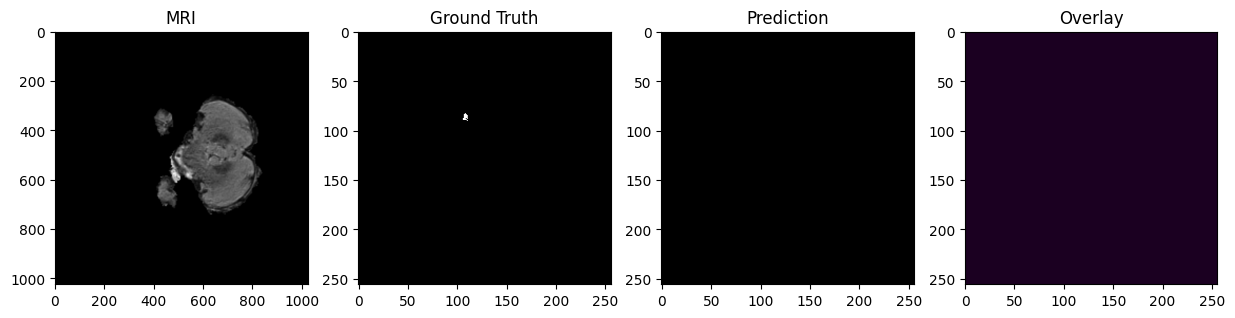

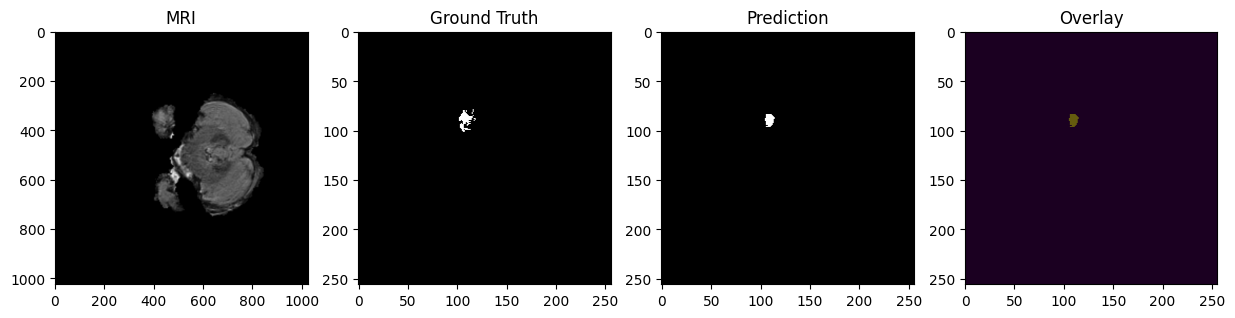

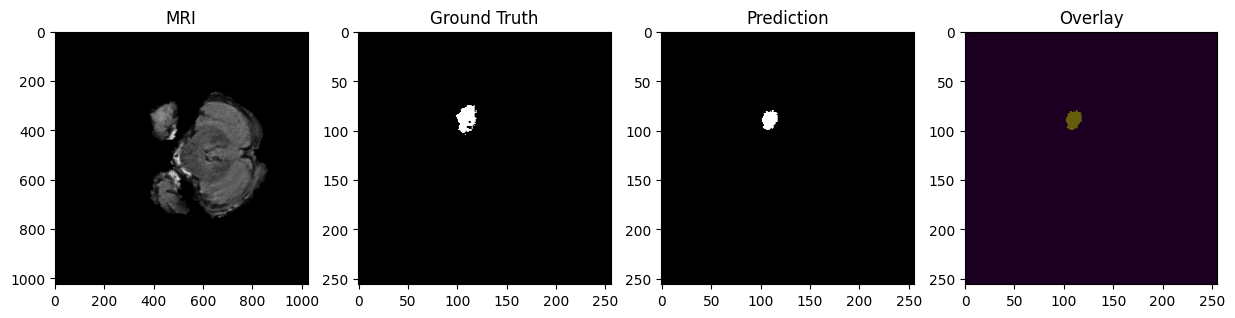

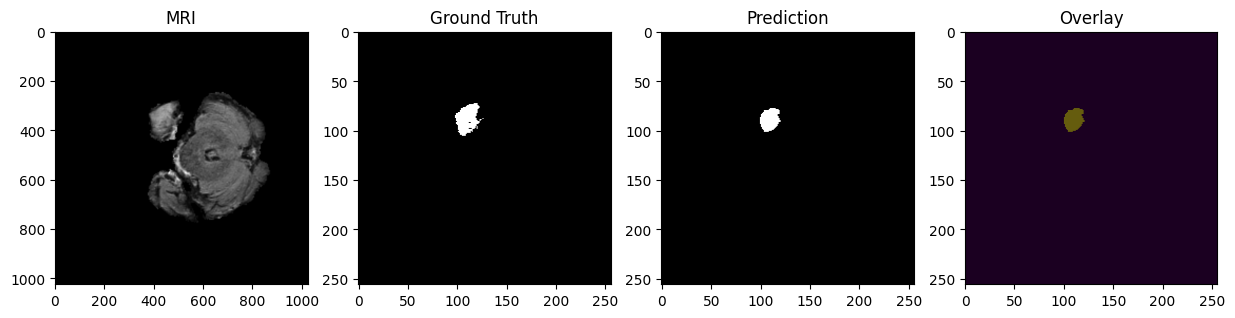

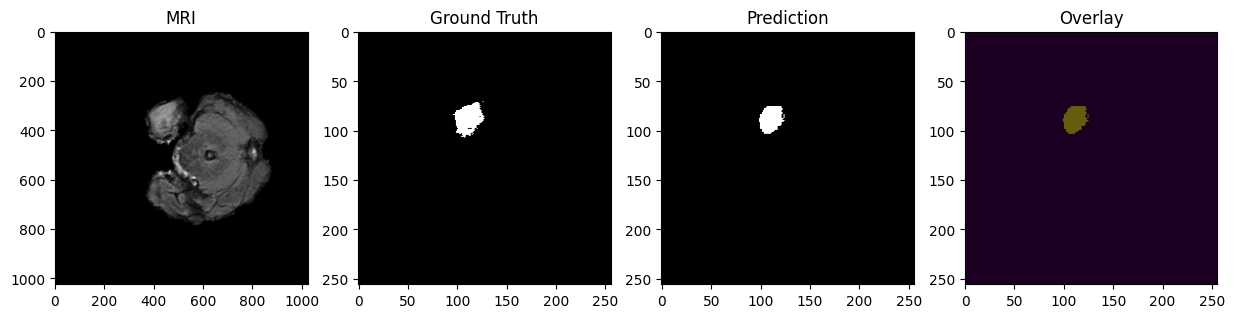

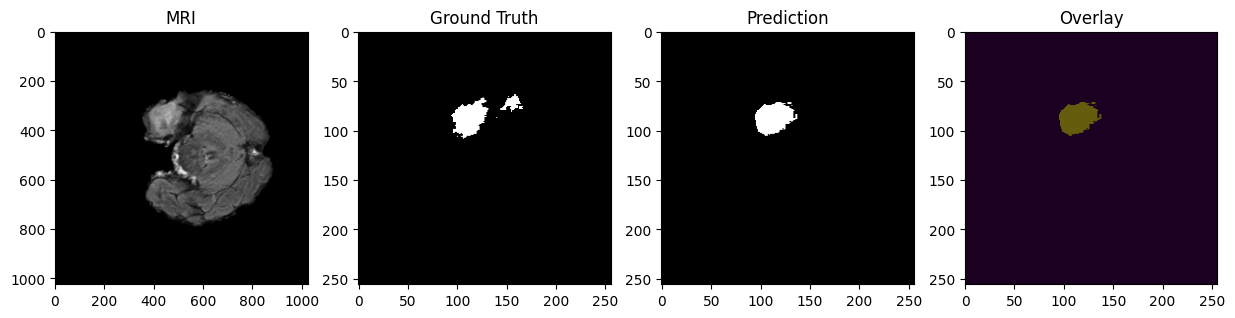

In [29]:
for i, batch in enumerate(val_loader):
    show_result(batch)
    if i == 5:
        break